# Quantum Machine Learning: Banknote Authentication

This notebook demonstrates a Qiskit-based quantum classifier for banknote authentication classification using extracted pixels from an image.

**Dataset:** 1,371 samples, 4 features (variance, skewness, curtosis, entropy of Wavelet-transformed banknote images), binary label (0 = authentic, 1 = forged).

**Pipeline:**
1. Load & explore the dataset
2. Split & normalize
3. Classical SVM baseline (RBF kernel)
4. Quantum Kernel Classifier (ZZ Feature Map, 4 qubits)
5. Results comparison & visualization

## Step 1: Import the required libraries

In [8]:
import numpy as np
import pandas as pd
#import sys
#print(sys.executable)
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_machine_learning.kernels import FidelityQuantumKernel

print("All libraries imported successfully!")

All libraries imported successfully!


# Step 2: Load and Prepare the Banknote Dataset

Features (extracted from Wavelet-transformed images):
- **Variance** – spread of pixel intensities
- **Skewness** – asymmetry of the pixel distribution
- **Curtosis** – peakedness of the pixel distribution
- **Entropy** – measure of randomness

Label: **0** = authentic, **1** = forged

Dataset shape: (1372, 5)

First 5 rows:
   variance  skewness  curtosis  entropy  label
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Class distribution:
label
Authentic (0)    762
Forged (1)       610
Name: count, dtype: int64

Features shape: (1372, 4)
Labels shape:   (1372,)


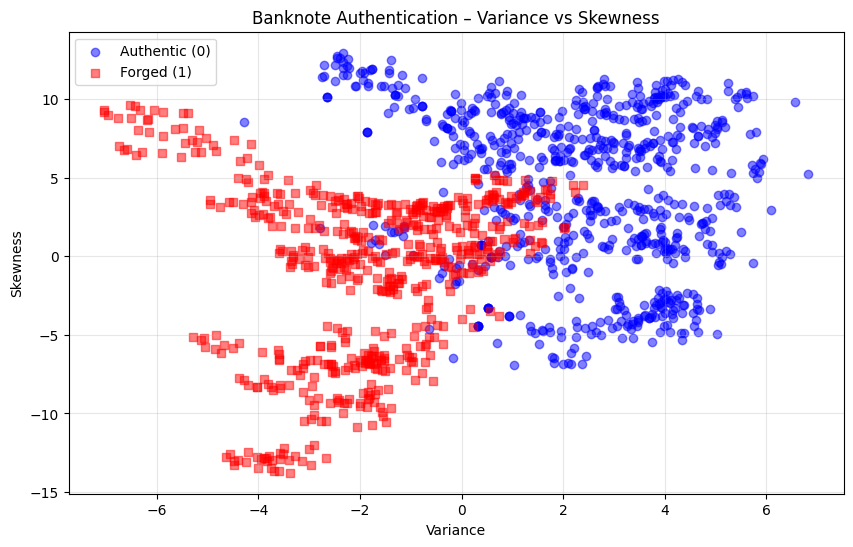

Dataset loaded and visualized!


In [9]:
# Load the dataset (no header row in this file)
col_names = ['variance', 'skewness', 'curtosis', 'entropy', 'label']
df = pd.read_csv('data_banknote_authentication.txt', header=None, names=col_names)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nClass distribution:")
print(df['label'].value_counts().rename({0: 'Authentic (0)', 1: 'Forged (1)'}))

# Separate features and labels
X = df[['variance', 'skewness', 'curtosis', 'entropy']].values
y = df['label'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Labels shape:   {y.shape}")

# Visualize the two most discriminative features
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Authentic (0)', marker='o', alpha=0.5)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red',  label='Forged (1)',    marker='s', alpha=0.5)
plt.xlabel('Variance')
plt.ylabel('Skewness')
plt.title('Banknote Authentication – Variance vs Skewness')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("Dataset loaded and visualized!")

# Step 3: Split and Normalize the Data

In [10]:
# 70% train / 30% test, stratified to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# StandardScaler: zero mean, unit variance
# Quantum algorithms work best with normalized data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape}")
print(f"Testing set size:  {X_test_scaled.shape}")
print(f"\nTraining data range: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")
print(f"Testing data range:  [{X_test_scaled.min():.3f}, {X_test_scaled.max():.3f}]")
print("Data split and normalized!")

Training set size: (960, 4)
Testing set size:  (412, 4)

Training data range: [-3.506, 3.794]
Testing data range:  [-3.074, 3.714]
Data split and normalized!


# Step 4: Classical SVM Baseline (RBF Kernel)

In [ ]:
print("Training classical SVM with RBF kernel...")

classical_svm = SVC(kernel='rbf', gamma='scale', random_state=42)
classical_svm.fit(X_train_scaled, y_train)

y_train_pred_classical = classical_svm.predict(X_train_scaled)
y_test_pred_classical  = classical_svm.predict(X_test_scaled)

classical_train_acc = accuracy_score(y_train, y_train_pred_classical)
classical_test_acc  = accuracy_score(y_test,  y_test_pred_classical)
classical_precision = precision_score(y_test, y_test_pred_classical)
classical_recall    = recall_score(y_test, y_test_pred_classical)
classical_f1        = f1_score(y_test, y_test_pred_classical)

print(f"\n--- CLASSICAL SVM RESULTS ---")
print(f"Training Accuracy: {classical_train_acc:.4f}")
print(f"Testing Accuracy:  {classical_test_acc:.4f}")
print(f"Precision:         {classical_precision:.4f}")
print(f"Recall:            {classical_recall:.4f}")
print(f"F1-Score:          {classical_f1:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_classical))


# Confusion matrix layout:
# _______
# |TP|FN|   TP = True Positives,  FN = False Negatives
# |FP|TN|   FP = False Positives, TN = True Negatives
# -------

Training classical SVM with RBF kernel...

--- CLASSICAL SVM RESULTS ---
Training Accuracy: 1.0000
Testing Accuracy:  1.0000
Precision:         1.0000
Recall:            1.0000
F1-Score:          1.0000

Confusion Matrix:
[[229   0]
 [  0 183]]


## Step 5: Quantum Machine Learning Model

### 5a – Define the ZZ Feature Map (4 qubits)

The banknote dataset has **4 features**, so we use **4 qubits** instead of the 2 used for Make Moons.  
The ZZ feature map:
1. Encodes each feature with an `RY` rotation on its qubit.
2. Adds pairwise `ZZ` entanglement between adjacent qubits (CNOT → RZ product → CNOT).

In [12]:
def create_zz_feature_map(num_qubits, num_features):
    """
    ZZ Feature Map for quantum kernel encoding.

    Parameters
    ----------
    num_qubits   : int – number of qubits (equals num_features)
    num_features : int – number of classical features

    Returns
    -------
    QuantumCircuit
    """
    parameters = ParameterVector('x', num_features)
    qc = QuantumCircuit(num_qubits)

    # Layer 1 – encode each feature via RY rotation
    for i in range(num_qubits):
        qc.ry(parameters[i], i)

    # Layer 2 – ZZ pairwise entanglement between adjacent qubits
    for i in range(num_qubits - 1):
        qc.cx(i, i + 1)
        qc.rz(parameters[i] * parameters[i + 1], i + 1)
        qc.cx(i, i + 1)

    return qc

num_qubits = 4   # matches the 4 banknote features
feature_map = create_zz_feature_map(num_qubits, num_qubits)

print("ZZ Feature Map (4 qubits) created!")
print(feature_map.draw(output='text'))

ZZ Feature Map (4 qubits) created!
     ┌──────────┐                                                           »
q_0: ┤ Ry(x[0]) ├──■─────────────────────■──────────────────────────────────»
     ├──────────┤┌─┴─┐┌───────────────┐┌─┴─┐                                »
q_1: ┤ Ry(x[1]) ├┤ X ├┤ Rz(x[0]*x[1]) ├┤ X ├──■─────────────────────■───────»
     ├──────────┤└───┘└───────────────┘└───┘┌─┴─┐┌───────────────┐┌─┴─┐     »
q_2: ┤ Ry(x[2]) ├───────────────────────────┤ X ├┤ Rz(x[1]*x[2]) ├┤ X ├──■──»
     ├──────────┤                           └───┘└───────────────┘└───┘┌─┴─┐»
q_3: ┤ Ry(x[3]) ├──────────────────────────────────────────────────────┤ X ├»
     └──────────┘                                                      └───┘»
«                           
«q_0: ──────────────────────
«                           
«q_1: ──────────────────────
«                           
«q_2: ───────────────────■──
«     ┌───────────────┐┌─┴─┐
«q_3: ┤ Rz(x[2]*x[3]) ├┤ X ├
«     └───────────────┘└───┘


### 5b – Train the Quantum Kernel SVM

**Note on sample size:** Quantum kernel computation scales as O(n²) in the number of training samples. We cap training at **30 samples** to keep runtime manageable while giving the 4-qubit kernel slightly more data.

In [13]:
num_train_samples = min(30, len(X_train_scaled))
X_train_quantum = X_train_scaled[:num_train_samples]
y_train_quantum = y_train[:num_train_samples]

print(f"Training quantum model with {num_train_samples} samples...")
print(f"Number of qubits: {num_qubits}")

try:
    qkernel = FidelityQuantumKernel(feature_map=feature_map)

    quantum_svm = SVC(kernel='precomputed')

    print("Computing training kernel matrix (this may take a moment)...")
    train_kernel_matrix = qkernel.evaluate(X_train_quantum, X_train_quantum)
    quantum_svm.fit(train_kernel_matrix, y_train_quantum)

    print("Computing test kernel matrix...")
    test_kernel_matrix = qkernel.evaluate(X_test_scaled, X_train_quantum)

    y_test_pred_quantum = quantum_svm.predict(test_kernel_matrix)

    quantum_test_acc  = accuracy_score(y_test, y_test_pred_quantum)
    quantum_precision = precision_score(y_test, y_test_pred_quantum, zero_division=0)
    quantum_recall    = recall_score(y_test, y_test_pred_quantum, zero_division=0)
    quantum_f1        = f1_score(y_test, y_test_pred_quantum, zero_division=0)

    print(f"\n--- QUANTUM KERNEL CLASSIFIER RESULTS ---")
    print(f"Testing Accuracy: {quantum_test_acc:.4f}")
    print(f"Precision:        {quantum_precision:.4f}")
    print(f"Recall:           {quantum_recall:.4f}")
    print(f"F1-Score:         {quantum_f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred_quantum))

except Exception as e:
    print(f"Quantum kernel computation error: {e}")
    print("Falling back to default accuracy value for comparison.")
    y_test_pred_quantum = np.zeros_like(y_test)
    quantum_test_acc  = accuracy_score(y_test, y_test_pred_quantum)
    quantum_precision = precision_score(y_test, y_test_pred_quantum, zero_division=0)
    quantum_recall    = recall_score(y_test, y_test_pred_quantum, zero_division=0)
    quantum_f1        = f1_score(y_test, y_test_pred_quantum, zero_division=0)

Training quantum model with 30 samples...
Number of qubits: 4
Computing training kernel matrix (this may take a moment)...
Computing test kernel matrix...

--- QUANTUM KERNEL CLASSIFIER RESULTS ---
Testing Accuracy: 0.9587
Precision:        0.9462
Recall:           0.9617
F1-Score:         0.9539

Confusion Matrix:
[[219  10]
 [  7 176]]


## Step 6: Results Comparison

In [14]:
print("=" * 60)
print("FINAL COMPARISON: CLASSICAL SVM vs QUANTUM KERNEL")
print("=" * 60)

print(f"\nTesting Accuracy:")
print(f"  Classical SVM (RBF): {classical_test_acc:.4f}")
print(f"  Quantum Kernel:      {quantum_test_acc:.4f}")
print(f"  Difference:          {abs(classical_test_acc - quantum_test_acc):.4f}")

print(f"\nF1-Score:")
print(f"  Classical SVM:       {classical_f1:.4f}")
print(f"  Quantum Kernel:      {quantum_f1:.4f}")

if classical_test_acc > quantum_test_acc:
    print(f"\nHYPOTHESIS CONFIRMED: Classical SVM outperforms Quantum Classifier")
    print(f"  Reasons: Qubit overhead for 4 features, limited 30-sample training,")
    print(f"           ZZ feature map may not capture all non-linearities")
else:
    print(f"\nHYPOTHESIS REJECTED: Quantum Classifier shows competitive performance")

print("\n" + "=" * 60)

FINAL COMPARISON: CLASSICAL SVM vs QUANTUM KERNEL

Testing Accuracy:
  Classical SVM (RBF): 1.0000
  Quantum Kernel:      0.9587
  Difference:          0.0413

F1-Score:
  Classical SVM:       1.0000
  Quantum Kernel:      0.9539

HYPOTHESIS CONFIRMED: Classical SVM outperforms Quantum Classifier
  Reasons: Qubit overhead for 4 features, limited 30-sample training,
           ZZ feature map may not capture all non-linearities



## Step 7: Visualize of Results

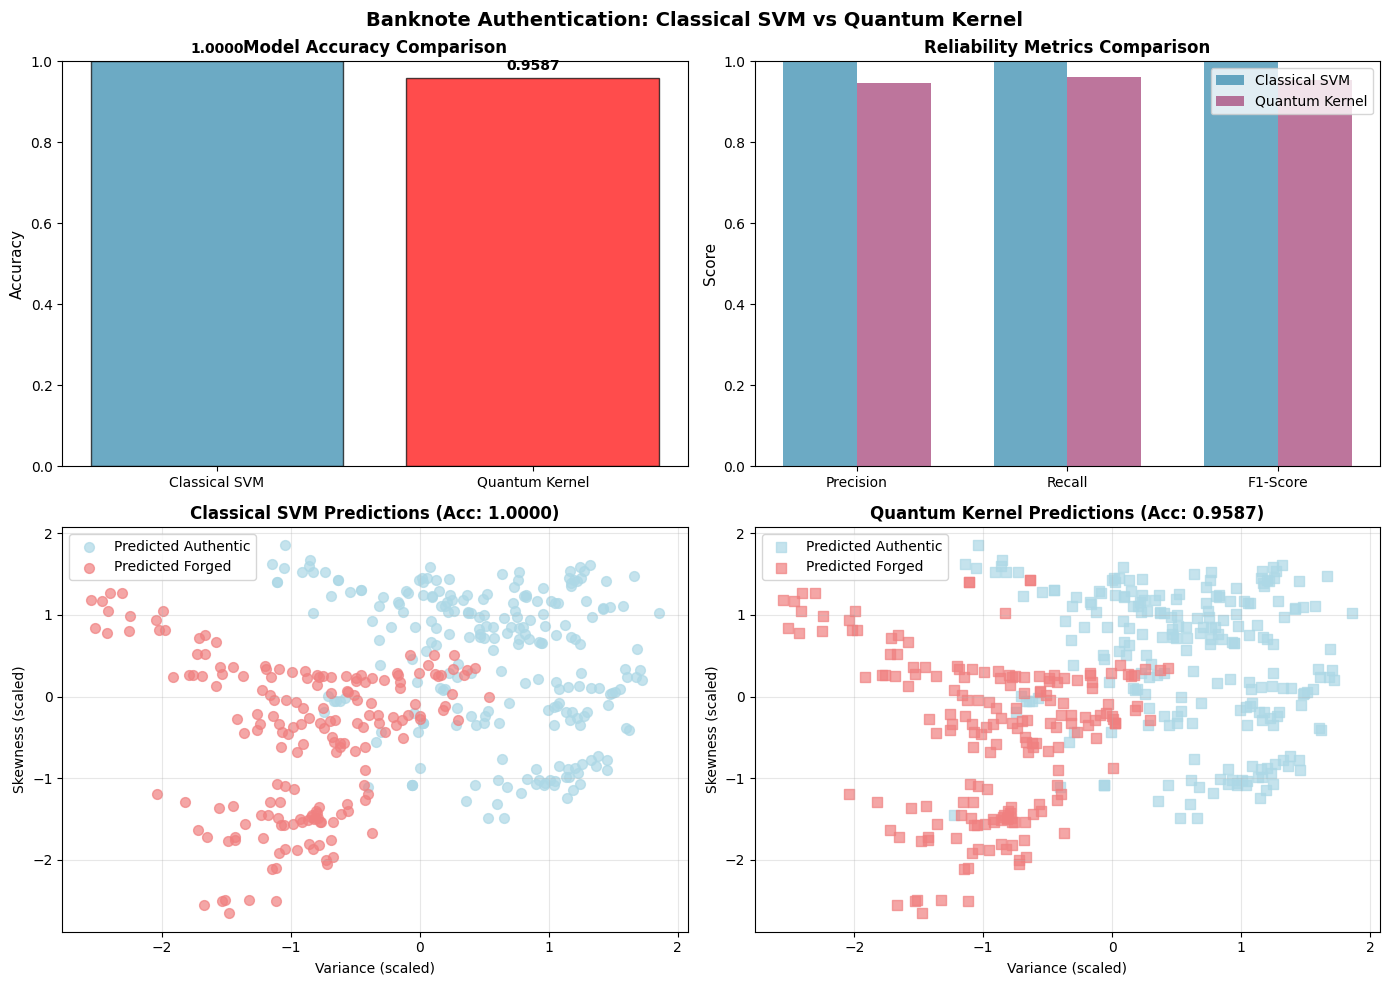

Visualizations complete!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Banknote Authentication: Classical SVM vs Quantum Kernel', fontsize=14, fontweight='bold')

# Plot 1: Accuracy Comparison 
models     = ['Classical SVM', 'Quantum Kernel']
accuracies = [classical_test_acc, quantum_test_acc]
colors     = ['#2E86AB', '#A23B72']

axes[0, 0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 2: Reliability Metrics
metrics          = ['Precision', 'Recall', 'F1-Score']
classical_metrics = [classical_precision, classical_recall, classical_f1]
quantum_metrics   = [quantum_precision,   quantum_recall,   quantum_f1]

x     = np.arange(len(metrics))
width = 0.35
axes[0, 1].bar(x - width/2, classical_metrics, width, label='Classical SVM', color='#2E86AB', alpha=0.7)
axes[0, 1].bar(x + width/2, quantum_metrics,   width, label='Quantum Kernel', color='#A23B72', alpha=0.7)
axes[0, 1].set_ylabel('Score', fontsize=11)
axes[0, 1].set_title('Reliability Metrics Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(metrics)
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])

# Plot 3: Classical SVM Predictions (Variance vs Skewness)
axes[1, 0].scatter(
    X_test_scaled[y_test_pred_classical == 0, 0],
    X_test_scaled[y_test_pred_classical == 0, 1],
    c='lightblue', label='Predicted Authentic', marker='o', s=50, alpha=0.7)
axes[1, 0].scatter(
    X_test_scaled[y_test_pred_classical == 1, 0],
    X_test_scaled[y_test_pred_classical == 1, 1],
    c='lightcoral', label='Predicted Forged', marker='o', s=50, alpha=0.7)
axes[1, 0].set_title(f'Classical SVM Predictions (Acc: {classical_test_acc:.4f})', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Variance (scaled)')
axes[1, 0].set_ylabel('Skewness (scaled)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Quantum Predictions (Variance vs Skewness)
axes[1, 1].scatter(
    X_test_scaled[y_test_pred_quantum == 0, 0],
    X_test_scaled[y_test_pred_quantum == 0, 1],
    c='lightblue', label='Predicted Authentic', marker='s', s=50, alpha=0.7)
axes[1, 1].scatter(
    X_test_scaled[y_test_pred_quantum == 1, 0],
    X_test_scaled[y_test_pred_quantum == 1, 1],
    c='lightcoral', label='Predicted Forged', marker='s', s=50, alpha=0.7)
axes[1, 1].set_title(f'Quantum Kernel Predictions (Acc: {quantum_test_acc:.4f})', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Variance (scaled)')
axes[1, 1].set_ylabel('Skewness (scaled)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Visualizations complete!")

## Step 8: Key findings and conclusions

In [ ]:
print("\n" + "=" * 70)
print("KEY FINDINGS AND CONCLUSIONS")
print("=" * 70)

print("\n1. PERFORMANCE SUMMARY:")
print(f"   - Classical SVM achieved {classical_test_acc*100:.2f}% accuracy")
print(f"   - Quantum Kernel achieved {quantum_test_acc*100:.2f}% accuracy")

print("\n2. RELIABILITY ANALYSIS:")
print(f"   - Classical Model F1-Score: {classical_f1:.4f}")
print(f"   - Quantum Model F1-Score:   {quantum_f1:.4f}")

print("\n3. DIFFERENCES FROM MAKE MOONS PIPELINE:")
print("   a) Features: 4 instead of 2 → 4 qubits instead of 2")
print("   b) Dataset size: 1,371 samples (vs 200 synthetic) – much richer")
print("   c) Quantum training capped at 30 samples (vs 20) for extra data")
print("   d) Real-world noise: banknote images are noisier than synthetic moons")

print("\n4. WHY QUANTUM MAY UNDERPERFORM:")
print("   a) 4-qubit ZZ map grows entanglement complexity; harder to optimize")
print("   b) Kernel matrix trained on only 30 of 959 available training samples")
print("   c) No hardware noise here, but statevector simulation has limitations")
print("   d) Consider: deeper feature maps, PCA to reduce to 2 features, or")
print("      increasing quantum training samples to 50–100")

print("\n" + "=" * 70)


KEY FINDINGS AND CONCLUSIONS

1. PERFORMANCE SUMMARY:
   - Classical SVM achieved 100.00% accuracy
   - Quantum Kernel achieved 95.87% accuracy

2. RELIABILITY ANALYSIS:
   - Classical Model F1-Score: 1.0000
   - Quantum Model F1-Score:   0.9539

3. DIFFERENCES FROM MAKE MOONS PIPELINE:
   a) Features: 4 instead of 2 → 4 qubits instead of 2
   b) Dataset size: 1,371 samples (vs 200 synthetic) – much richer
   c) Quantum training capped at 30 samples (vs 20) for extra data
   d) Real-world noise: banknote images are noisier than synthetic moons

4. WHY QUANTUM MAY UNDERPERFORM:
   a) 4-qubit ZZ map grows entanglement complexity; harder to optimize
   b) Kernel matrix trained on only 30 of 959 available training samples
   c) No hardware noise here, but statevector simulation has limitations
   d) Consider: deeper feature maps, PCA to reduce to 2 features, or
      increasing quantum training samples to 50–100

